In [1]:
import os
if 'PATH_SET' not in locals():
    os.chdir('../..')
    PATH_SET = True
    
import torch    

if 'THREADS_SET' not in locals():
    try:
        os.environ['OMP_NUM_THREADS'] = '1'
        os.environ['MKL_NUM_THREADS'] = '1'
        
        torch.set_num_threads(1)
        torch.set_num_interop_threads(1)
        THREADS_SET = True
    except:
        pass

import numpy as np

import xarray as xr
import shapely

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.style as style
style.use('https://raw.githubusercontent.com/dominik-strutz/dotfiles/main/mystyle_background.mplstyle')

figure_path = 'figures/priors/data_prior/'
os.makedirs(figure_path, exist_ok=True)

In [2]:
from helpers.geographic_setup import (
    design_space_full, design_space_shoulder,
    events_shoulder, events_full,
    topo_data
)

In [3]:
topo_spacing = 15

topo_data = topo_data.interp(
    easting=np.arange(topo_data.easting.min(), topo_data.easting.max(), topo_spacing),
    northing=np.arange(topo_data.northing.min(), topo_data.northing.max(), topo_spacing)
)

x_min, x_max, x_N = (
    topo_data.easting.values.min(),
    topo_data.easting.values.max(),
    topo_data.easting.size)

y_min, y_max, y_N = (
    topo_data.northing.values.min(),
    topo_data.northing.values.max(),
    topo_data.northing.size)

z_min, z_max = (
    topo_data.values.min()-300,
    topo_data.values.max()
)
dz = 5
z_N = int((z_max - z_min) // dz) # 2 m resolution

x = np.linspace(x_min, x_max, x_N)
y = np.linspace(y_min, y_max, y_N)
z = np.linspace(z_min, z_max, z_N)

print(f'x: {x_min} - {x_max} ({x_N})')
print(f'y: {y_min} - {y_max} ({y_N})')
print(f'z: {z_min} - {z_max} ({z_N})')

x: 0.0 - 2475.0 (166)
y: 0.0 - 2475.0 (166)
z: 1204.3962499999998 - 2678.9849999999997 (294)


In [4]:
vp_grid = xr.DataArray(
    np.moveaxis(np.linspace(z_min, z_max, z_N).repeat(x_N * y_N).reshape(z_N, x_N, y_N), 0, -1),
    dims=('easting', 'northing', 'elevation'),
    coords={
        'easting': x,
        'northing': y,
        'elevation': z
    }
)

In [5]:
import pandas as pd
from helpers.geographic_setup import MIN_EASTING, MIN_NORTHING

filename_vpfile = 'data/velocity_model/2d_profile_final/vp2D_2Draycov.csv'
vp = np.loadtxt(filename_vpfile, delimiter=',').T

profile_file = 'data/velocity_model/2d_profile_final/ProfileXYZ.csv'
profilexyz = pd.read_csv(
    profile_file, header=0,
    names=['X', 'Y', 'Z'])

profilexyz['X'] -= MIN_EASTING
profilexyz['Y'] -= MIN_NORTHING

profile_x = profilexyz['X'].values
profile_y = profilexyz['Y'].values
profile_z = profilexyz['Z'].values

vp_z = np.linspace(profile_z.max()-1000, profile_z.max(), vp.shape[1])

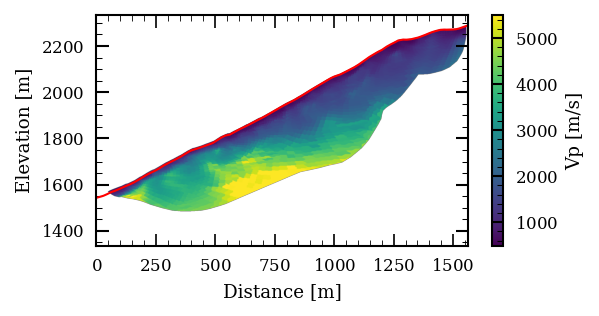

In [6]:
profile_elevations = (topo_data.interp(
    easting=xr.DataArray(profile_x, dims='points'),
    northing=xr.DataArray(profile_y, dims='points')).values)

fig, ax = plt.subplots(1, 1, figsize=(4, 2))
ax.plot(profile_elevations,
        label='Profile',
        color='red', lw=1)

im = ax.imshow(vp.T, aspect='auto', cmap='viridis', zorder=-1,
          extent=[0, vp.shape[0], vp_z[0], vp_z[-1]])

ax.set_xlabel('Distance [m]')
ax.set_ylabel('Elevation [m]')

plt.colorbar(im, ax=ax, label='Vp [m/s]')
    
plt.show()

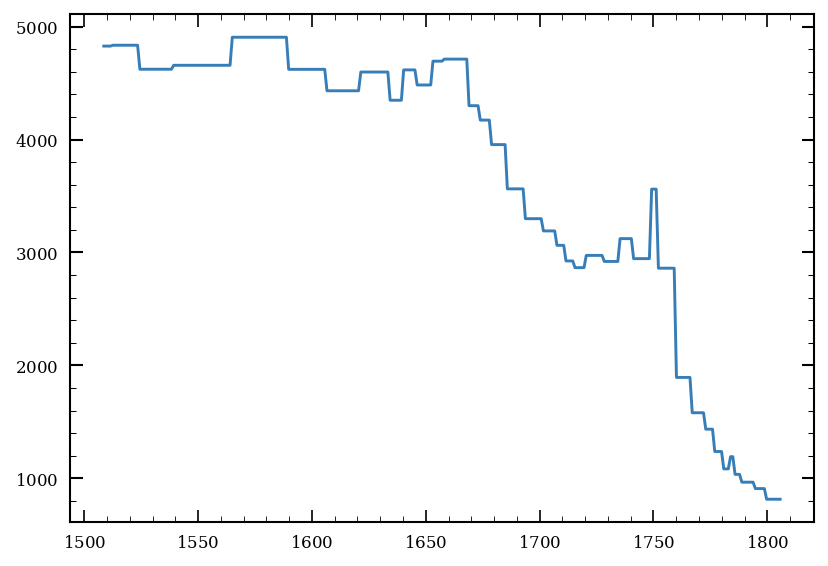

In [7]:
def extract_1D_profile(elevation, vp, profile_elevations):
    index = np.argmin(np.abs(profile_elevations - elevation))    
    return vp[index, ::-1]
    
plt.plot(vp_z, extract_1D_profile(1800.0, vp, profile_elevations))
plt.show()

/tmp/ipykernel_411334/3165277612.py:13: RuntimeWarning: Mean of empty slice
  mean_vert_profile = np.nanmean(vert_profiles,axis=0)


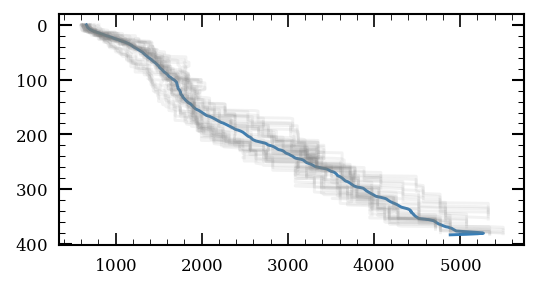

In [8]:
# find mean vert profile
vert_profile_list = []
for z_i in profile_elevations:
    
    if z_i > 2000 and z_i < 2200:
        local_profile = extract_1D_profile(z_i, vp, profile_elevations)
        # shift local profile to the right
        local_profile = np.interp(np.linspace(z_i-1000, z_i, local_profile.shape[0]), np.linspace(vp_z.min(), vp_z.max(), local_profile.shape[0]), local_profile)
        
        vert_profile_list.append(local_profile)
    
vert_profiles = np.stack(vert_profile_list)
mean_vert_profile = np.nanmean(vert_profiles,axis=0)
mean_vert_profile = np.nan_to_num(mean_vert_profile, nan=max(mean_vert_profile))

fig, ax = plt.subplots(1, 1, figsize=(4, 2))

ax.plot(mean_vert_profile[::-1], np.linspace(0, 1000, mean_vert_profile.size))
for vp_i in vert_profiles[::10]:
    ax.plot(vp_i[::-1], np.linspace(0, 1000, vp_i.size), color='gray', alpha=0.1)

ax.invert_yaxis()
plt.show()

/tmp/ipykernel_411334/1109815335.py:15: RuntimeWarning: All-NaN slice encountered
  local_profile[np.isnan(local_profile)] = np.nanmax(local_profile)


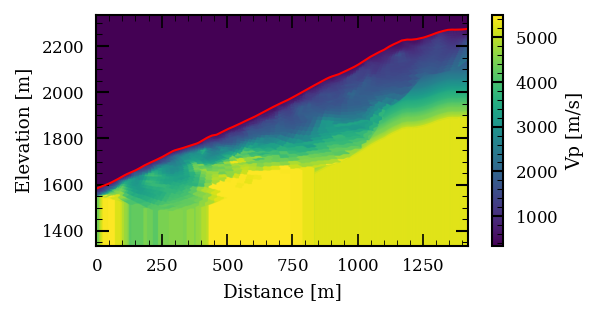

In [9]:
vp_filled = np.ones_like(vp).copy()*330.0

for i, z in enumerate(profile_elevations):
    if z > 2030:
        vp_filled[i] = extract_1D_profile(z, vp, profile_elevations)[::-1]
        # add the mean vert profile shifted to the correct elevation
        mean_profile = np.interp(np.linspace(vp_z.min(), vp_z.max(), vp_filled[i].shape[0]), np.linspace(z-1000, z, mean_vert_profile.size), mean_vert_profile)[::-1]
        mean_profile[np.isnan(mean_profile)] = np.nanmax(mean_profile)
        vp_filled[i] = mean_profile
    
    local_profile = extract_1D_profile(z, vp, profile_elevations)[::-1].copy()
    
    # fill all nan values on below the profile with the max value
    if z < 2030:
        local_profile[np.isnan(local_profile)] = np.nanmax(local_profile)
    
    # set everything above the profile to nan
    local_profile[vp_z[::-1] > z] = 330.0
    
    vp_filled[i][~np.isnan(local_profile)] = local_profile[~np.isnan(local_profile)]
    
# from scipy.ndimage import gaussian_filter
# vp_filled = gaussian_filter(vp_filled, sigma=4)

profile_elevations = (topo_data.interp(
    easting=xr.DataArray(profile_x, dims='points'),
    northing=xr.DataArray(profile_y, dims='points')).values)
profile_elevations = profile_elevations[100:-40]
vp_filled          = vp_filled[100:-40]


fig, ax = plt.subplots(1, 1, figsize=(4, 2))
ax.plot(profile_elevations,
        label='Profile',
        color='red', lw=1)

im = ax.imshow(
    vp_filled.T, aspect='auto', cmap='viridis', zorder=-1,
    extent=[0, vp_filled.shape[0], vp_z[0], vp_z[-1]])

ax.set_xlabel('Distance [m]')
ax.set_ylabel('Elevation [m]')

plt.colorbar(im, ax=ax, label='Vp [m/s]')

plt.show()

In [10]:
for i_x, x_i in tqdm(enumerate(vp_grid.easting.values), total=x_N):
    for i_y, y_i in enumerate(vp_grid.northing.values):
        
        elevation = topo_data.interp(easting=x_i, northing=y_i, method='nearest').values
                        
        vert_profile = extract_1D_profile(min(elevation, profile_elevations.max()), vp_filled, profile_elevations)

        z = vp_grid.elevation
        
        if elevation <= profile_elevations.max() and elevation >= profile_elevations.min():
            # interpolate to grid
            vert_profile = np.interp(z, vp_z, vert_profile)
        elif elevation > profile_elevations.max():
            vert_profile = np.interp(
                z, vp_z + (elevation - profile_elevations.max()), vert_profile)
        else:
            vert_profile = np.interp(
                z, vp_z - (profile_elevations.min() - elevation), vert_profile)
        
        vp_grid[i_x, i_y, :] = vert_profile

  0%|          | 0/166 [00:00<?, ?it/s]

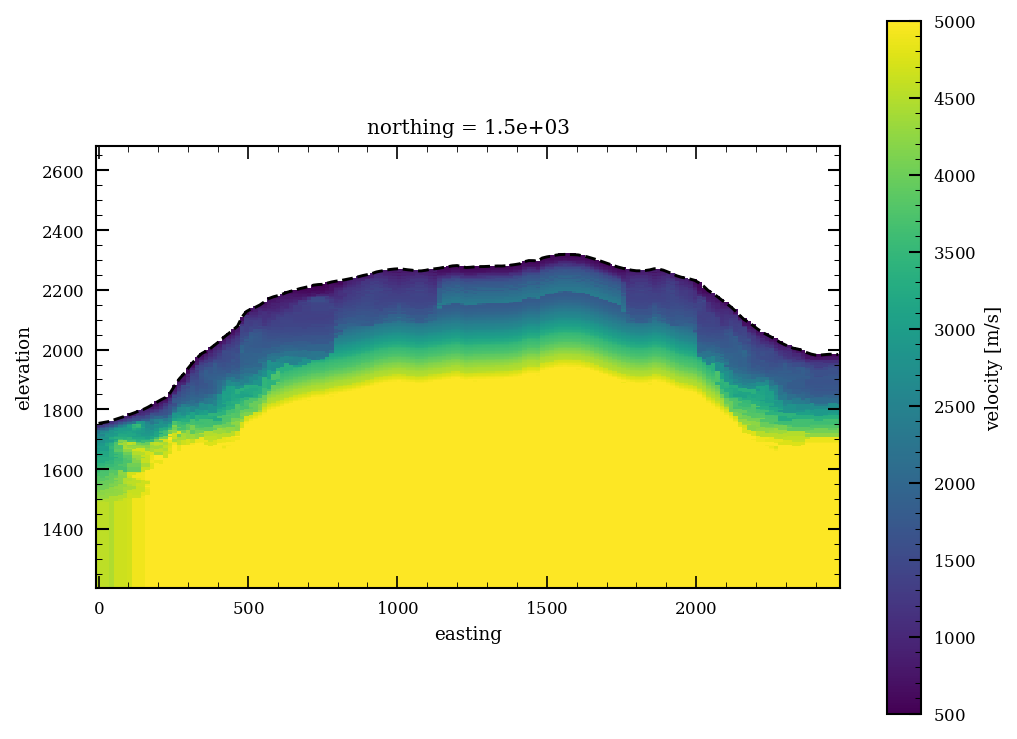

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

test_northing=1500

im_values = vp_grid.sel(northing=test_northing, method='nearest').T
im_values = xr.where(im_values < 500, np.nan, im_values) 

im_values.plot.imshow(ax=ax, cmap='viridis', vmin=500, vmax=5000, add_colorbar=False)
ax.set_aspect('equal')

topo_data.sel(northing=test_northing, method='nearest').plot(ax=ax, color='k', linestyle='--')

# ax.set_xlim([x[0], x[-1]])
# ax.set_ylim([z[0], z[-1]])
# ax.axhline(vp_z.max())        

plt.colorbar(ax.images[0], ax=ax, label='velocity [m/s]')

plt.show()

vp model bounds:
511.54000899987295 1931.540008999873 (356,)
1131.6799999999348 1607.6799999999348 (120,)
1718.2709155270331 2414.270915527033 (175,)


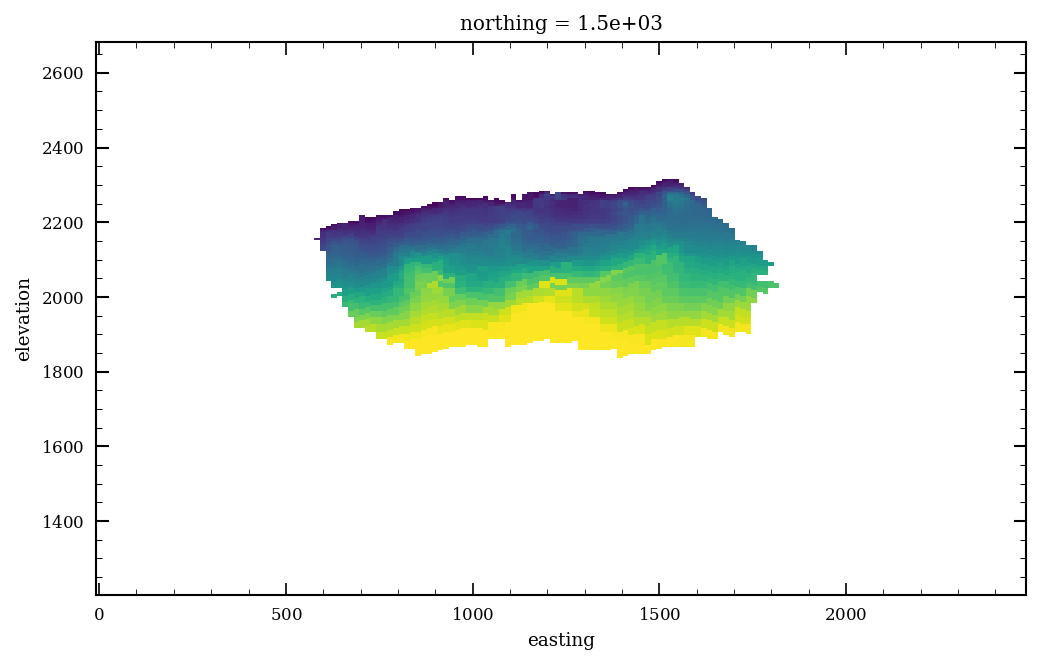

In [12]:
vp_model_shoulder = xr.load_dataarray(
    'data/velocity_model/3d_model_final/vp_xarray_raycovered.nc',
    engine='netcdf4',
    format='NETCDF4'
    )

print('vp model bounds:')
print(vp_model_shoulder.easting.min().values, vp_model_shoulder.easting.max().values, vp_model_shoulder.easting.shape)
print(vp_model_shoulder.northing.min().values, vp_model_shoulder.northing.max().values, vp_model_shoulder.northing.shape)
print(vp_model_shoulder.elevation.min().values, vp_model_shoulder.elevation.max().values, vp_model_shoulder.elevation.shape)

center_easting = vp_model_shoulder.easting.mean()
center_northing = vp_model_shoulder.northing.mean()
top_elevation = vp_model_shoulder.elevation.max()

vp_model_shoulder = vp_model_shoulder.interp(
    easting=vp_grid.easting,
    northing=vp_grid.northing,
    elevation=vp_grid.elevation, method='nearest')

# make it a bit smaller to only have the well resolved part
# set everything below circle at top center with radius 500m to nan

# vp_model_shoulder = xr.where(
#     (vp_model_shoulder.easting - center_easting)**2 + (vp_model_shoulder.northing - center_northing)**2 + (vp_model_shoulder.elevation - top_elevation)**2 > 500**2,
#     300.0, vp_model_shoulder)

fig, ax = plt.subplots(figsize=(8, 6))

test_northing=1500

im_values = vp_model_shoulder.sel(northing=test_northing, method='nearest').T
im_values = xr.where(im_values < 600, np.nan, im_values) 

im_values.plot.imshow(ax=ax, cmap='viridis', vmin=500, vmax=5000, add_colorbar=False)
ax.set_aspect('equal')

plt.show()

In [27]:
from scipy.ndimage import gaussian_filter

vp_grid = vp_grid.where(
    (vp_model_shoulder.isnull() | (vp_model_shoulder < 350.0)), vp_model_shoulder)

mask = vp_grid.values < 350
vp_grid.values = np.where(
    mask, vp_grid.values, gaussian_filter(
       np.where(vp_grid.values < 350, 550, vp_grid.values),
       sigma=1, mode='nearest'))


vp_grid.to_netcdf(
    'data/velocity_model/vel_model_heterogeneous.nc',format='NETCDF4', engine='netcdf4')

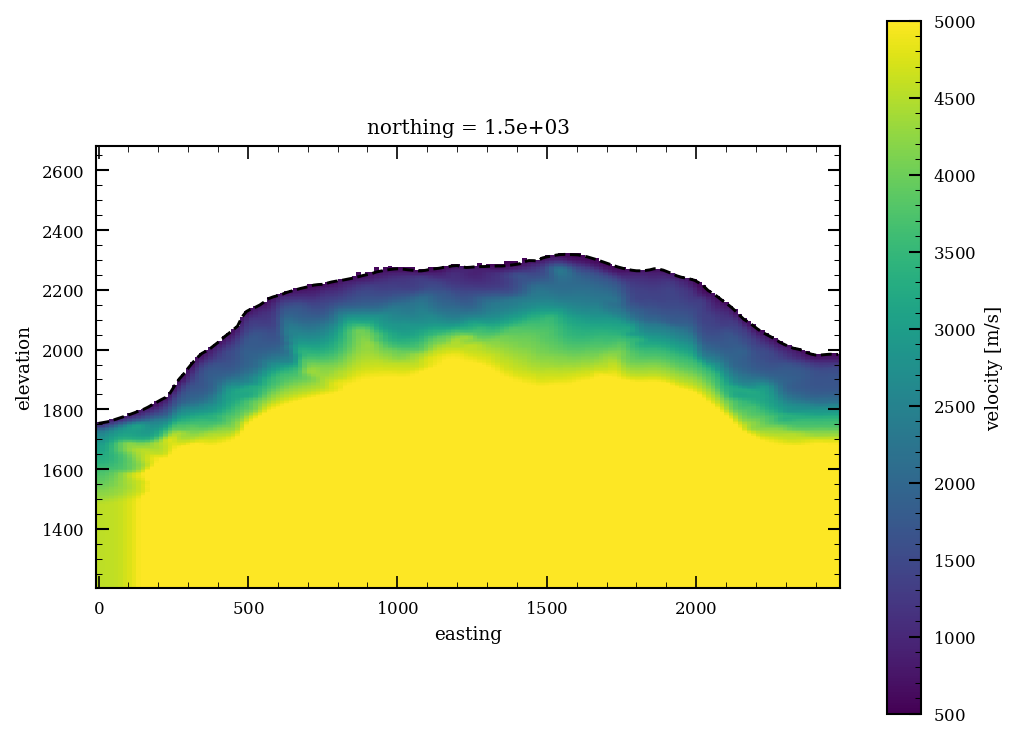

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

test_northing=1500

im_values = vp_grid.sel(northing=test_northing, method='nearest').T
im_values = xr.where(im_values < 500, np.nan, im_values) 

im_values.plot.imshow(ax=ax, cmap='viridis', vmin=500, vmax=5000, add_colorbar=False)
ax.set_aspect('equal')

topo_data.sel(northing=test_northing, method='nearest').plot(ax=ax, color='k', linestyle='--')

plt.colorbar(ax.images[0], ax=ax, label='velocity [m/s]')

plt.show()

In [28]:
vp_grid_smooth = vp_grid.copy()

# vp_grid_smooth.values = gaussian_filter(vp_grid.values, sigma=5)
# smooth only for values above 350 m/s
mask = vp_grid.values < 350
vp_grid_smooth.values = np.where(
    mask, vp_grid.values, gaussian_filter(
       np.where(vp_grid.values < 350, 550, vp_grid.values),
       sigma=2, mode='nearest'))


vp_grid_smooth.to_netcdf(
    'data/velocity_model/vel_model_heterogeneous_smooth.nc',format='NETCDF4', engine='netcdf4')

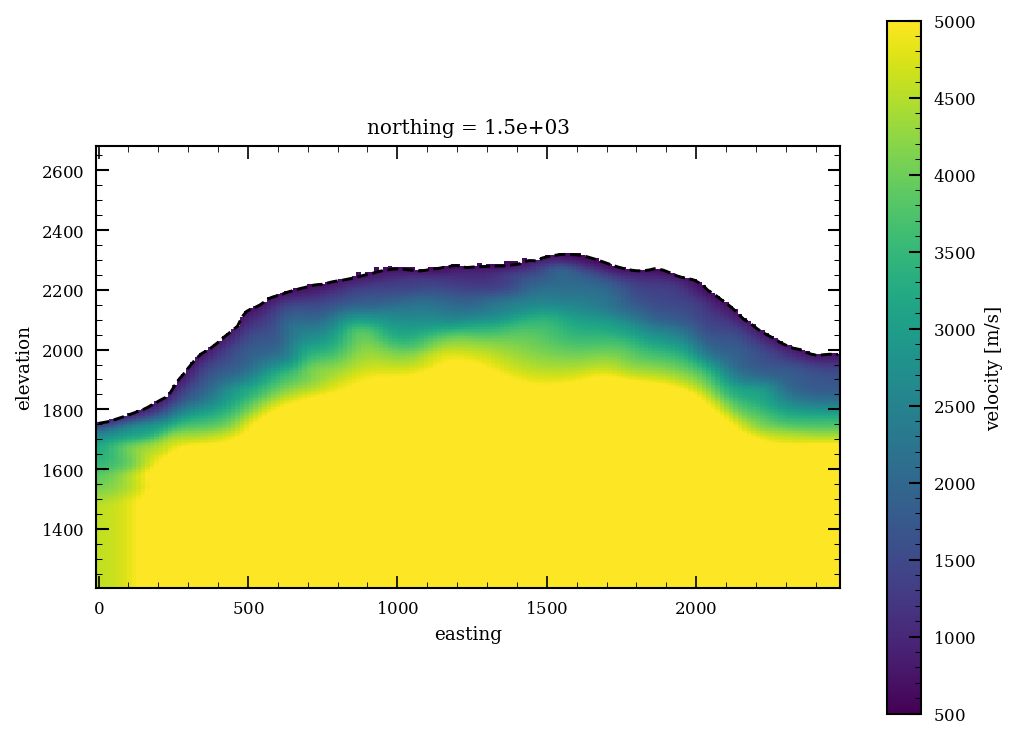

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

test_northing=1500

im_values = vp_grid_smooth.sel(northing=test_northing, method='nearest').T
im_values = xr.where(im_values < 500, np.nan, im_values) 

im_values.plot.imshow(ax=ax, cmap='viridis', vmin=500, vmax=5000, add_colorbar=False)
ax.set_aspect('equal')

topo_data.sel(northing=test_northing, method='nearest').plot(ax=ax, color='k', linestyle='--')


plt.colorbar(ax.images[0], ax=ax, label='velocity [m/s]')

plt.show()

In [17]:
prior_samples_full_disp = torch.load('data/priors/prior_samples_full_disp.pt')
prior_samples_full_uniform = torch.load('data/priors/prior_samples_full_uniform.pt')
posterior_grid_full = torch.load('data/priors/full_posterior_grid.pt')

In [18]:
import pykonal

class Pykonal_Forward:
    def __init__(self, x, y, z, seismic_grid):
        self.x_min, self.x_max, self.x_N = x.min(), x.max(), x.size
        self.y_min, self.y_max, self.y_N = y.min(), y.max(), y.size
        self.z_min, self.z_max, self.z_N = z.min(), z.max(), z.size      

        self.dx = (x_max - x_min) / x_N
        self.dy = (y_max - y_min) / y_N
        self.dz = (z_max - z_min) / z_N
                
        self.seismic_grid = seismic_grid
                
    def forward(self, source_coords):
        
        # receiver_vert = get_elevation(receiver_coords[..., :2], topo_ds_interp)
        # receiver_coords = np.hstack([receiver_coords, receiver_vert[:, None]])
        
        solver = pykonal.solver.PointSourceSolver()
        solver.velocity.min_coords     = self.x_min, self.y_min, self.z_min
        solver.velocity.node_intervals = self.dx, self.dy, self.dz
        solver.velocity.npts           = self.x_N, self.y_N, self.z_N
        solver.velocity.values         = self.seismic_grid.values
        
        solver.src_loc = source_coords
        solver.solve()
        
        return solver.traveltime

pyk_forward_original = Pykonal_Forward(x, y, z, vp_grid)
pyk_forward_smooth = Pykonal_Forward(x, y, z, vp_grid_smooth)

In [19]:
data_path = 'data/data_lookup'
os.makedirs(data_path, exist_ok=True)

In [23]:
full_disp_data_path = f'{data_path}/heterogeneous_full_disp.pt'
full_uniform_data_path = f'{data_path}/heterogeneous_full_uniform.pt'
full_posterior_data_path = f'{data_path}/heterogeneous_full_posterior.pt'

print(os.path.exists(full_disp_data_path), 
    os.path.exists(full_uniform_data_path), 
    os.path.exists(full_posterior_data_path))

# Try to load existing data
if (os.path.exists(full_disp_data_path) and 
    os.path.exists(full_uniform_data_path) and 
    os.path.exists(full_posterior_data_path)):
    
    print("Loading pre-computed data...")
    full_disp_data = torch.load(full_disp_data_path)
    full_uniform_data = torch.load(full_uniform_data_path)
else:
    print("Computing and saving data...")
    
    
    full_disp_data = torch.zeros(
        len(prior_samples_full_disp), len(design_space_full))

    full_uniform_data = torch.zeros(
        len(prior_samples_full_uniform), len(design_space_full))
    
    full_posterior_data = torch.zeros(
        len(posterior_grid_full), len(design_space_full))
    
    for i, receiver in tqdm(
        enumerate(design_space_full),
        total=len(design_space_full)):

        out = pyk_forward_smooth.forward(
                source_coords=receiver[..., :3].double().numpy())     

        full_disp_data[:, i] = torch.tensor(out.resample(
            prior_samples_full_disp[..., :3].double().numpy()
            )).float()
            
        full_uniform_data[:, i] = torch.tensor(out.resample(
            prior_samples_full_uniform[..., :3].double().numpy()
            )).float()
        
        full_posterior_data[:, i] = torch.tensor(out.resample(
            posterior_grid_full[..., :3].double().numpy()
            )).float()
        

    # Save computed data
    torch.save(full_disp_data, full_disp_data_path)
    torch.save(full_uniform_data, full_uniform_data_path)
    torch.save(full_posterior_data, full_posterior_data_path)

True True True
Loading pre-computed data...


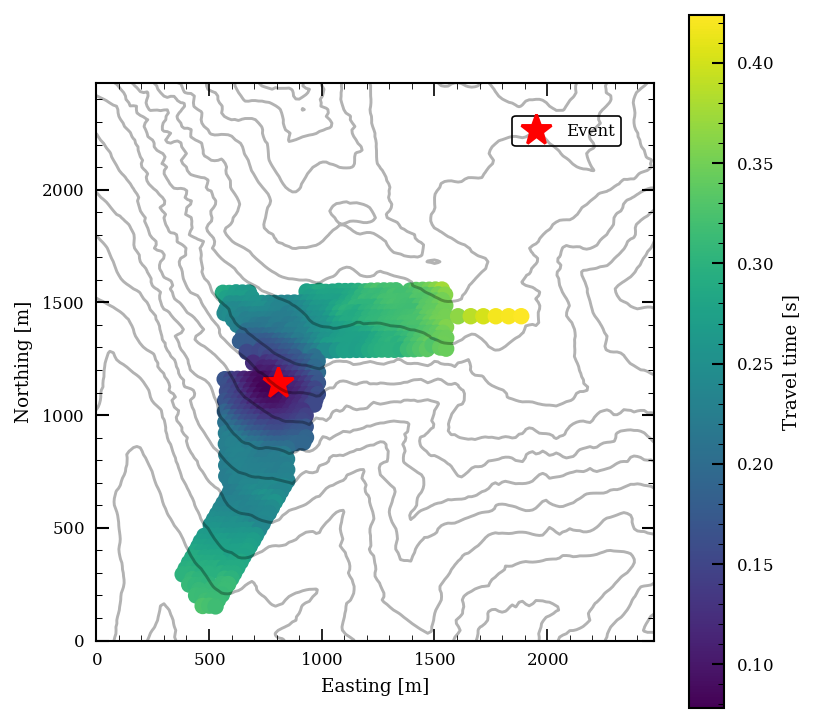

In [24]:
# Define event index
event_idx = 100

fig, ax = plt.subplots(figsize=(6, 6))

# Get the specified event's data for all receivers
event_data = full_disp_data[event_idx]

# Create scatter plot using receiver locations from design_space_full
scatter = ax.scatter(
    design_space_full[:, 0],  # easting
    design_space_full[:, 1],  # northing
    c=event_data,       # color by travel time
    cmap='viridis',
    s=50               # marker size
)

# Plot the event location (specified event from prior_samples_full_disp)
ax.plot(
    prior_samples_full_disp[event_idx, 0],
    prior_samples_full_disp[event_idx, 1],
    'r*',
    markersize=15,
    label='Event'
)

# Add colorbar
plt.colorbar(scatter, label='Travel time [s]')

# Add contours of topography
topo_data.T.plot.contour(ax=ax, levels=20, colors='k', alpha=0.3)

ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')
ax.set_aspect('equal')
ax.legend()

plt.show()

In [25]:
lines_shots_path = f'{data_path}/heterogeneous_full_shots.pt'

if os.path.exists(lines_shots_path):
    print("Loading pre-computed data...")
else:
    lines_shots_data = torch.zeros(
        len(events_full), len(design_space_full))
    
    print("Computing and saving data...")
    for i, event in tqdm(
        enumerate(events_full),
        total=len(events_full)):

        out = pyk_forward_original.forward(
                source_coords=event[:3].double().numpy())     
        lines_shots_data[i:, ] = torch.tensor(out.resample(
            design_space_full[..., :3].double().numpy()
            )).float()
    
    # Save computed data
    torch.save(lines_shots_data, lines_shots_path)

Loading pre-computed data...
